In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
uploaded = files.upload()
file_name = next(iter(uploaded))
print("Uploaded file:", file_name)

Saving Sydney_Housing_Data.xlsx to Sydney_Housing_Data (1).xlsx
Uploaded file: Sydney_Housing_Data (1).xlsx


In [3]:
df = pd.read_excel(file_name, sheet_name="Housing Data")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (105, 17)


,Property_ID,Address,Suburb,State,Postcode,Sale_Price_AUD,Sale_Date,Bedrooms,Bathrooms,Parking_Spaces,Land_Size_m2,Property_Type,Within_Budget_800k_1.2m,Listing_URL,Source_Page,Source_Website,Collected_On
0,SYD-001,"40 Stephen Street, Blacktown",Blacktown,NSW,2148,1350000,2026-09-17,5,3,3.0,338.0,House,No,https://www.realestate.com.au/sold/property-ho...,https://www.realestate.com.au/sold/property-ho...,realestate.com.au,2026-09-17
1,SYD-002,"7 Highlands Crescent, Blacktown",Blacktown,NSW,2148,1135000,2026-09-15,3,2,4.0,765.0,House,Yes,https://www.realestate.com.au/sold/property-ho...,https://www.realestate.com.au/sold/property-ho...,realestate.com.au,2026-09-17
2,SYD-003,"81 Reservoir Road, Blacktown",Blacktown,NSW,2148,1105000,2026-09-15,4,2,2.0,NaN,House,Yes,https://www.realestate.com.au/sold/property-ho...,https://www.realestate.com.au/sold/property-ho...,realestate.com.au,2026-09-17
3,SYD-004,"4 & 4A Joseph Street, Blacktown",Blacktown,NSW,2148,1340000,2026-09-14,5,2,1.0,713.0,House,No,https://www.realestate.com.au/sold/property-ho...,https://www.realestate.com.au/sold/property-ho...,realestate.com.au,2026-09-17
4,SYD-005,"42 Burke Street, Blacktown",Blacktown,NSW,2148,1260000,2026-09-11,5,3,6.0,NaN,House,No,https://www.realestate.com.au/sold/property-ho...,https://www.realestate.com.au/sold/property-ho...,realestate.com.au,2026-09-17


In [4]:
print("Number of observations:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn data types:")
display(df.dtypes.to_frame("Data type"))

print("\nSuburb distribution:")
display(df["Suburb"].value_counts().to_frame("Properties"))

Number of observations: 105
Number of columns: 17

Column data types:


,Data type
Property_ID,object
Address,object
Suburb,object
State,object
Postcode,int64
Sale_Price_AUD,int64
Sale_Date,datetime64[ns]
Bedrooms,int64
Bathrooms,int64
Parking_Spaces,float64



Suburb distribution:


,Properties
Suburb,
Blacktown,35
Campbelltown,35
Liverpool,35


In [5]:
quality_summary = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage": (df.isna().mean() * 100).round(1)
}).sort_values("Missing values", ascending=False)

display(quality_summary)
print("Duplicate complete rows:", df.duplicated().sum())
print("Duplicate addresses:", df["Address"].duplicated().sum())
print("Duplicate listing URLs:", df["Listing_URL"].duplicated().sum())
print("Missing listing URLs:", df["Listing_URL"].isna().sum())

,Missing values,Missing percentage
Land_Size_m2,29,27.6
Parking_Spaces,4,3.8
Property_ID,0,0.0
Address,0,0.0
Suburb,0,0.0
Sale_Price_AUD,0,0.0
Sale_Date,0,0.0
State,0,0.0
Postcode,0,0.0
Bathrooms,0,0.0


Duplicate complete rows: 0
Duplicate addresses: 0
Duplicate listing URLs: 0
Missing listing URLs: 0


In [6]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], errors="coerce")
df["Collected_On"] = pd.to_datetime(df["Collected_On"], errors="coerce")

numeric_columns = [
    "Sale_Price_AUD", "Bedrooms", "Bathrooms",
    "Parking_Spaces", "Land_Size_m2"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Sale dates:", df["Sale_Date"].min().date(), "to", df["Sale_Date"].max().date())
display(df[numeric_columns].describe().round(2))

Sale dates: 2026-03-14 to 2026-09-17


,Sale_Price_AUD,Bedrooms,Bathrooms,Parking_Spaces,Land_Size_m2
count,105.00,105.00,105.00,101.00,76.00
mean,1130548.14,3.87,1.83,1.92,663.07
std,358872.67,2.33,1.48,1.21,435.22
min,390000.00,2.00,1.00,1.00,135.00
25%,930000.00,3.00,1.00,1.00,555.50
50%,1070000.00,3.00,2.00,2.00,600.35
75%,1235000.00,4.00,2.00,2.00,704.68
max,3100000.00,24.00,14.00,6.00,3977.00


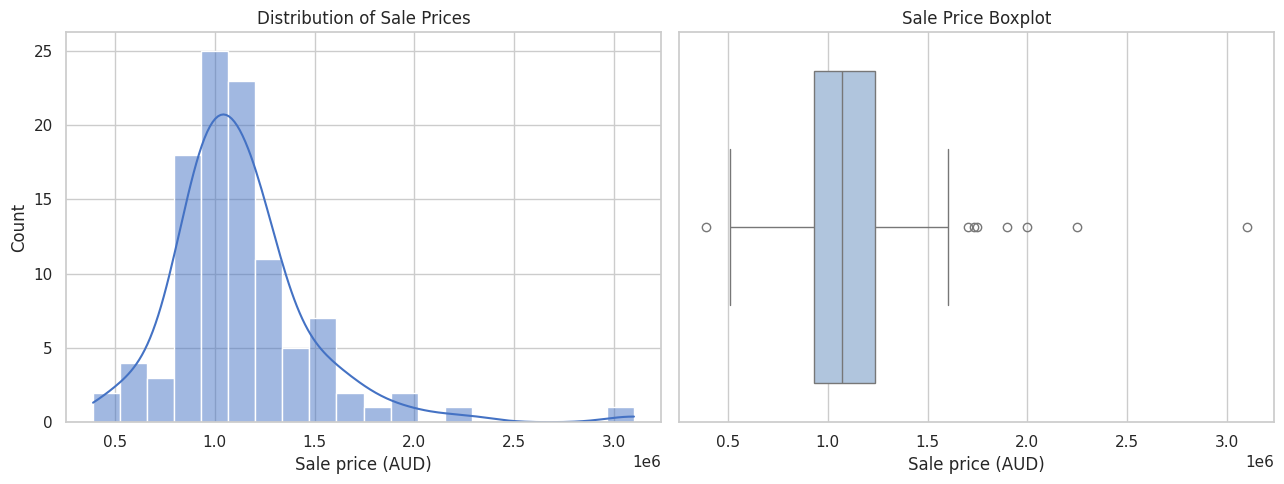

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["Sale_Price_AUD"], bins=20, kde=True, ax=axes[0], color="#4472C4")
axes[0].set_title("Distribution of Sale Prices")
axes[0].set_xlabel("Sale price (AUD)")

sns.boxplot(x=df["Sale_Price_AUD"], ax=axes[1], color="#A9C4E4")
axes[1].set_title("Sale Price Boxplot")
axes[1].set_xlabel("Sale price (AUD)")

plt.tight_layout()
plt.savefig("01_price_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

,Properties,Mean,Median,Minimum,Maximum
Suburb,,,,,
Blacktown,35,1160371.0,1105000.0,820000,1900000
Campbelltown,35,1005387.0,965000.0,510000,1750000
Liverpool,35,1225886.0,1150000.0,390000,3100000


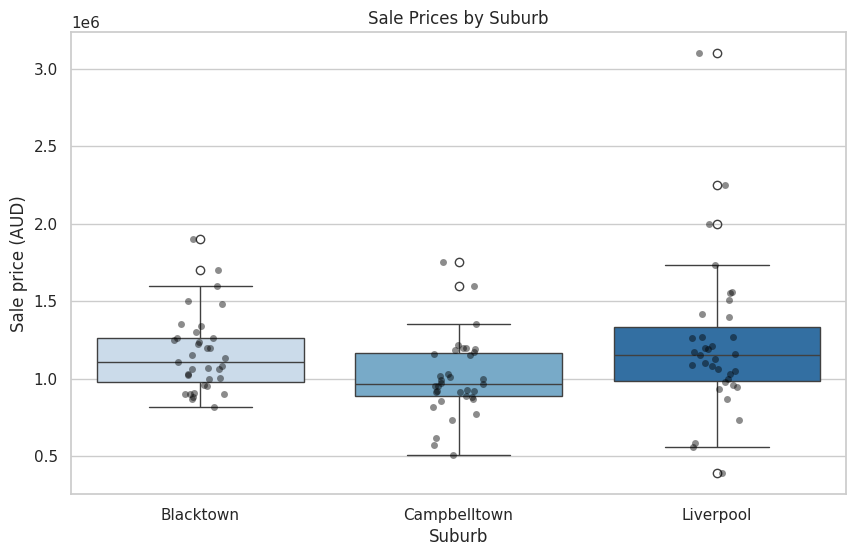

In [8]:
suburb_summary = df.groupby("Suburb")["Sale_Price_AUD"].agg(
    Properties="count",
    Mean="mean",
    Median="median",
    Minimum="min",
    Maximum="max"
).round(0)
display(suburb_summary)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Suburb", y="Sale_Price_AUD", palette="Blues")
sns.stripplot(data=df, x="Suburb", y="Sale_Price_AUD", color="black", alpha=0.45)
plt.title("Sale Prices by Suburb")
plt.ylabel("Sale price (AUD)")
plt.savefig("02_prices_by_suburb.png", dpi=200, bbox_inches="tight")
plt.show()

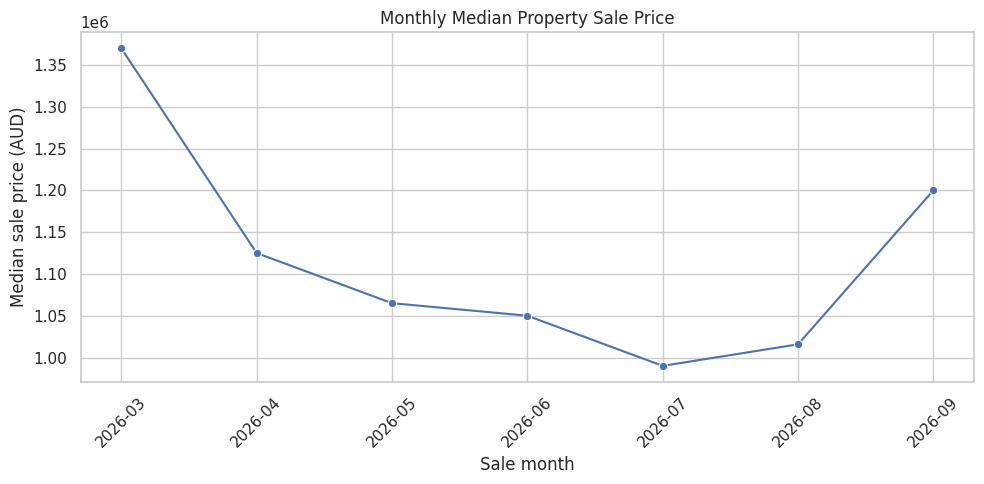

In [10]:
monthly_trend = (
    df.dropna(subset=["Sale_Date", "Sale_Price_AUD"])
    .assign(Month=lambda x: x["Sale_Date"].dt.to_period("M").astype(str))
    .groupby("Month")["Sale_Price_AUD"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_trend,
    x="Month",
    y="Sale_Price_AUD",
    marker="o"
)

plt.title("Monthly Median Property Sale Price")
plt.xlabel("Sale month")
plt.ylabel("Median sale price (AUD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

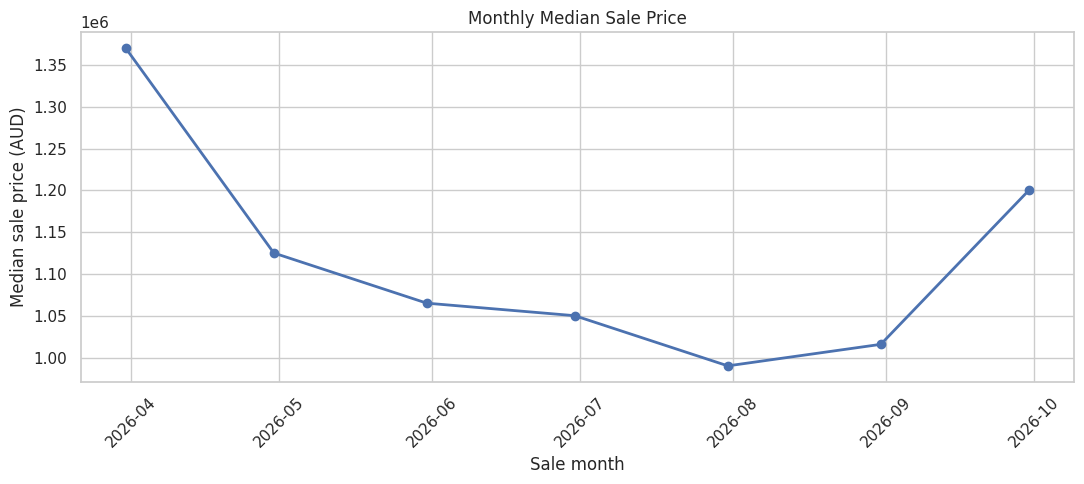

,Median sale price
Sale_Date,
2026-03-31,1370000.0
2026-04-30,1125000.0
2026-05-31,1065000.0
2026-06-30,1050000.0
2026-07-31,990000.0
2026-08-31,1015750.0
2026-09-30,1200000.0


In [11]:
monthly_prices = (
    df.set_index("Sale_Date")
      .resample("M")["Sale_Price_AUD"]
      .median()
      .dropna()
)

plt.figure(figsize=(11, 5))
plt.plot(monthly_prices.index, monthly_prices.values, marker="o", linewidth=2)
plt.title("Monthly Median Sale Price")
plt.xlabel("Sale month")
plt.ylabel("Median sale price (AUD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("03_monthly_price_trend.png", dpi=200, bbox_inches="tight")
plt.show()

display(monthly_prices.to_frame("Median sale price"))

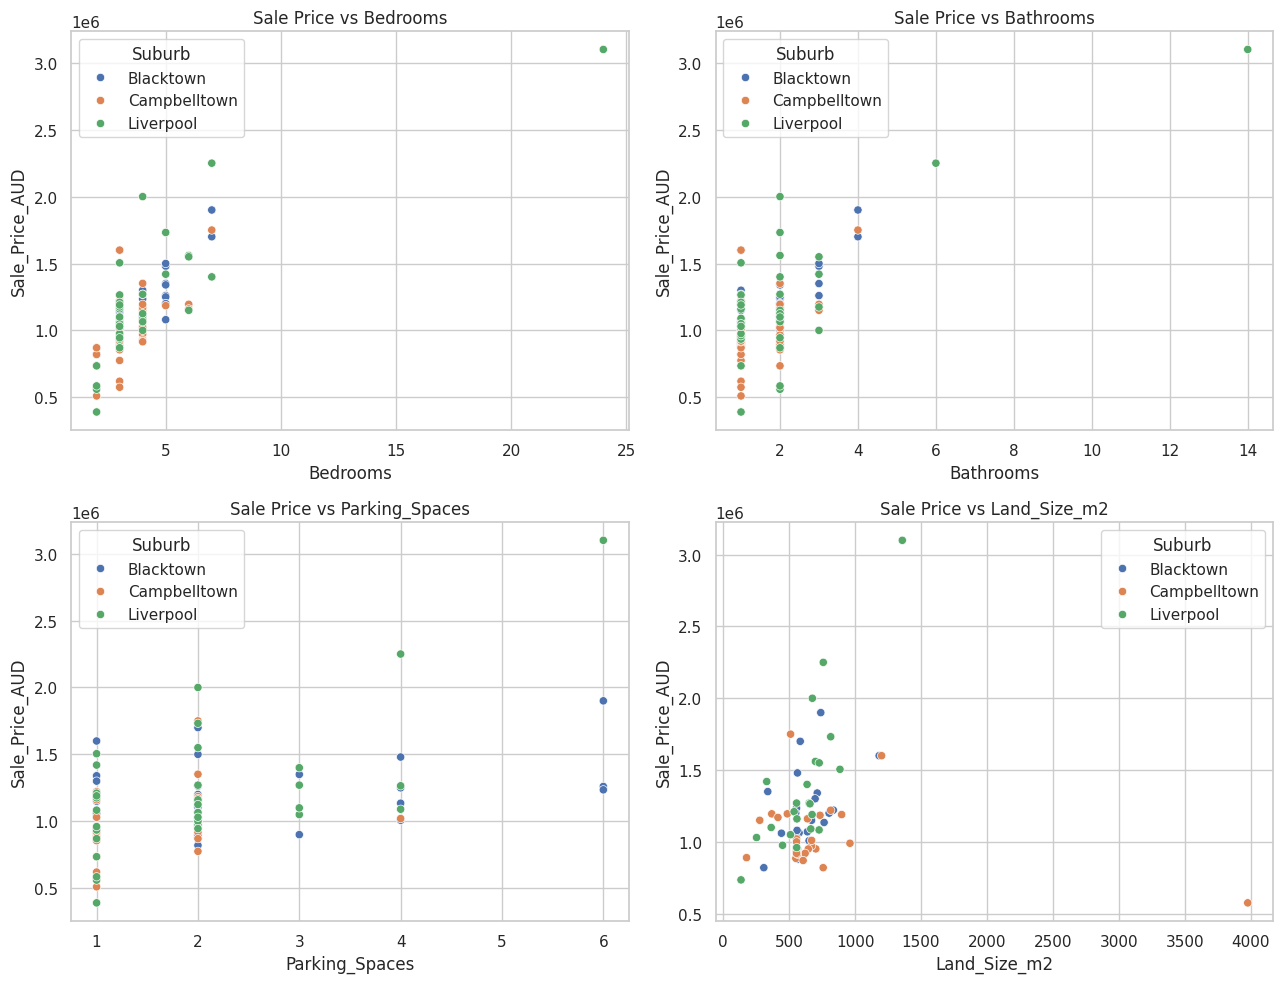

,Bedrooms,Bathrooms,Parking_Spaces,Land_Size_m2,Sale_Price_AUD
Bedrooms,1.000,0.904,0.458,0.139,0.773
Bathrooms,0.904,1.000,0.491,0.085,0.715
Parking_Spaces,0.458,0.491,1.000,0.010,0.480
Land_Size_m2,0.139,0.085,0.010,1.000,0.069
Sale_Price_AUD,0.773,0.715,0.480,0.069,1.000


In [12]:
plot_columns = ["Bedrooms", "Bathrooms", "Parking_Spaces", "Land_Size_m2"]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for column, axis in zip(plot_columns, axes.flatten()):
    sns.scatterplot(data=df, x=column, y="Sale_Price_AUD", hue="Suburb", ax=axis)
    axis.set_title(f"Sale Price vs {column}")

plt.tight_layout()
plt.savefig("04_feature_relationships.png", dpi=200, bbox_inches="tight")
plt.show()

display(df[plot_columns + ["Sale_Price_AUD"]].corr().round(3))

In [13]:
q1 = df["Sale_Price_AUD"].quantile(0.25)
q3 = df["Sale_Price_AUD"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

price_outliers = df[
    (df["Sale_Price_AUD"] < lower_limit) |
    (df["Sale_Price_AUD"] > upper_limit)
].copy()

print("IQR lower limit:", round(lower_limit, 2))
print("IQR upper limit:", round(upper_limit, 2))
print("Possible price outliers:", len(price_outliers))
display(price_outliers[[
    "Property_ID", "Address", "Suburb", "Sale_Price_AUD",
    "Bedrooms", "Bathrooms", "Land_Size_m2", "Listing_URL"
]].sort_values("Sale_Price_AUD", ascending=False))

IQR lower limit: 472500.0
IQR upper limit: 1692500.0
Possible price outliers: 8


,Property_ID,Address,Suburb,Sale_Price_AUD,Bedrooms,Bathrooms,Land_Size_m2,Listing_URL
77,SYD-078,"1 leitz street, Liverpool",Liverpool,3100000,24,14,1358.0,https://www.realestate.com.au/sold/property-ho...
101,SYD-102,"6 Tully Avenue, Liverpool",Liverpool,2250000,7,6,758.8,https://www.realestate.com.au/sold/property-ho...
70,SYD-071,"3 Secant Street, Liverpool",Liverpool,2000000,4,2,676.0,https://www.realestate.com.au/sold/property-ho...
13,SYD-014,"13 Lancaster Street, Blacktown",Blacktown,1900000,7,4,739.8,https://www.realestate.com.au/sold/property-ho...
52,SYD-053,"28 & 28A Westview Street, Campbelltown",Campbelltown,1750000,7,4,510.9,https://www.realestate.com.au/sold/property-ho...
99,SYD-100,"24 Rose Street, Liverpool",Liverpool,1732000,5,2,815.0,https://www.realestate.com.au/sold/property-ho...
30,SYD-031,"53 Pelleas Street, Blacktown",Blacktown,1700000,7,4,584.0,https://www.realestate.com.au/sold/property-ho...
88,SYD-089,"2/30-32 Goulburn Street, Liverpool",Liverpool,390000,2,1,NaN,https://www.realestate.com.au/sold/property-ot...


In [14]:
model_df = df.copy()

model_df["Total_Rooms"] = model_df["Bedrooms"] + model_df["Bathrooms"]
model_df["Land_Per_Bedroom"] = model_df["Land_Size_m2"] / model_df["Bedrooms"].replace(0, np.nan)
model_df["Sale_Month"] = model_df["Sale_Date"].dt.month
model_df["Sale_Quarter"] = model_df["Sale_Date"].dt.quarter
model_df["Days_Since_First_Sale"] = (
    model_df["Sale_Date"] - model_df["Sale_Date"].min()
).dt.days
model_df["Multi_Dwelling_Address"] = (
    model_df["Address"].str.contains(r"&| and ", case=False, regex=True).astype(int)
)

engineered = [
    "Total_Rooms", "Land_Per_Bedroom", "Sale_Month",
    "Sale_Quarter", "Days_Since_First_Sale", "Multi_Dwelling_Address"
]

display(model_df[engineered].head())

,Total_Rooms,Land_Per_Bedroom,Sale_Month,Sale_Quarter,Days_Since_First_Sale,Multi_Dwelling_Address
0,8,67.6,9,3,187,0
1,5,255.0,9,3,185,0
2,6,NaN,9,3,185,0
3,7,142.6,9,3,184,1
4,8,NaN,9,3,181,0


In [15]:
numeric_features = [
    "Bedrooms", "Bathrooms", "Parking_Spaces", "Land_Size_m2",
    "Total_Rooms", "Land_Per_Bedroom", "Sale_Month",
    "Sale_Quarter", "Days_Since_First_Sale", "Multi_Dwelling_Address"
]
categorical_features = ["Suburb", "Property_Type"]
feature_columns = numeric_features + categorical_features

X = model_df[feature_columns]
y = model_df["Sale_Price_AUD"]

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, model_df.index,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training properties:", len(X_train))
print("Testing properties:", len(X_test))

Training properties: 84
Testing properties: 21


In [16]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=2,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.04, max_depth=2,
        random_state=RANDOM_STATE
    )
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

print("Pipelines created:", list(pipelines.keys()))

Pipelines created: ['Linear Regression', 'Random Forest', 'Gradient Boosting']


In [17]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_rows = []
for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=kfold, scoring=scoring,
        return_train_score=True
    )
    cv_rows.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean(),
        "Train CV R2": scores["train_R2"].mean(),
        "R2 Gap": scores["train_R2"].mean() - scores["test_R2"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV RMSE")
display(cv_results.round(3))

,Model,CV MAE,CV RMSE,CV R2,Train CV R2,R2 Gap
1,Random Forest,159523.391,224497.016,0.348,0.832,0.484
2,Gradient Boosting,167658.777,227899.722,0.276,0.908,0.632
0,Linear Regression,192010.952,333444.632,-1.616,0.618,2.234


In [18]:
evaluation_rows = []
fitted_models = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    evaluation_rows.append({
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred)
    })

evaluation = pd.DataFrame(evaluation_rows).sort_values("Test RMSE")
display(evaluation.round(3))

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
2,Gradient Boosting,84174.743,143670.585,107582.960,242080.979,0.878,0.772
1,Random Forest,86727.187,159409.310,126738.846,301067.945,0.830,0.647
0,Linear Regression,138884.060,219543.718,199030.412,450297.656,0.582,0.210


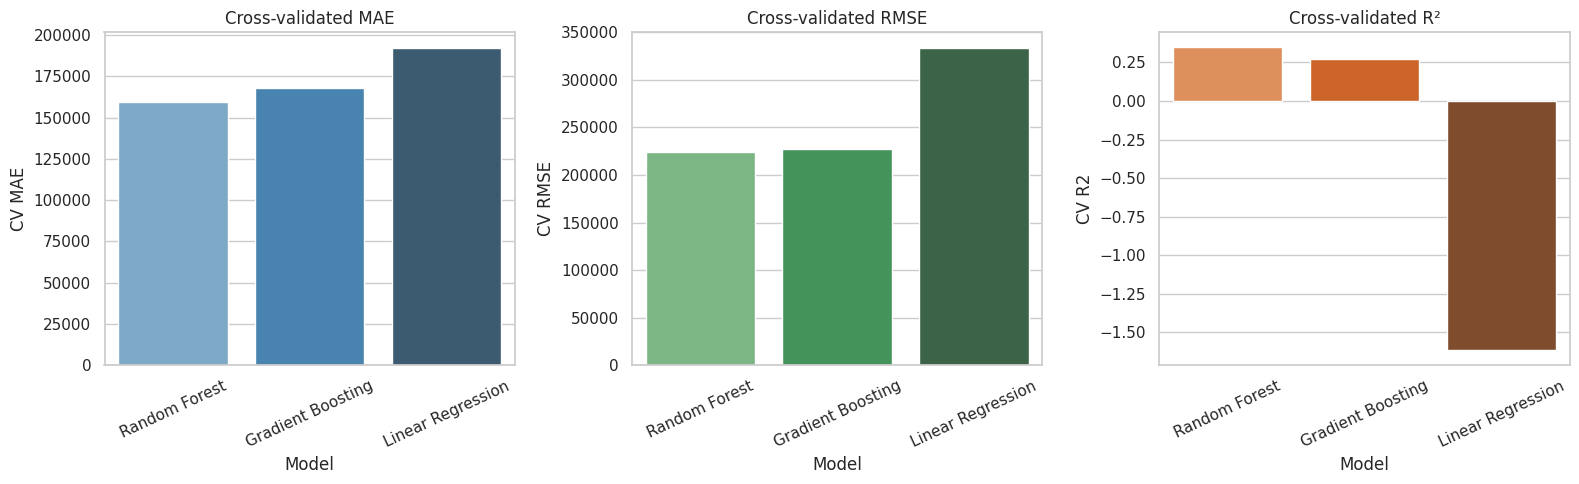

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=cv_results, x="Model", y="CV MAE", ax=axes[0], palette="Blues_d")
sns.barplot(data=cv_results, x="Model", y="CV RMSE", ax=axes[1], palette="Greens_d")
sns.barplot(data=cv_results, x="Model", y="CV R2", ax=axes[2], palette="Oranges_d")

axes[0].set_title("Cross-validated MAE")
axes[1].set_title("Cross-validated RMSE")
axes[2].set_title("Cross-validated R²")
for axis in axes:
    axis.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("05_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
best_model_name = cv_results.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Recommended model:", best_model_name)
print("Lowest CV RMSE:", round(cv_results.iloc[0]["CV RMSE"], 2))
print("CV R²:", round(cv_results.iloc[0]["CV R2"], 3))
print("Train-test and CV gaps should be discussed when evaluating overfitting.")

Recommended model: Random Forest
Lowest CV RMSE: 224497.02
CV R²: 0.348
Train-test and CV gaps should be discussed when evaluating overfitting.


,Feature,Importance
0,Bedrooms,75100.388273
4,Total_Rooms,54666.441951
3,Land_Size_m2,19100.799718
10,Suburb,17663.788392
1,Bathrooms,17288.138485
9,Multi_Dwelling_Address,0.000000
11,Property_Type,0.000000
7,Sale_Quarter,-85.899672
6,Sale_Month,-462.449305
2,Parking_Spaces,-1946.839732


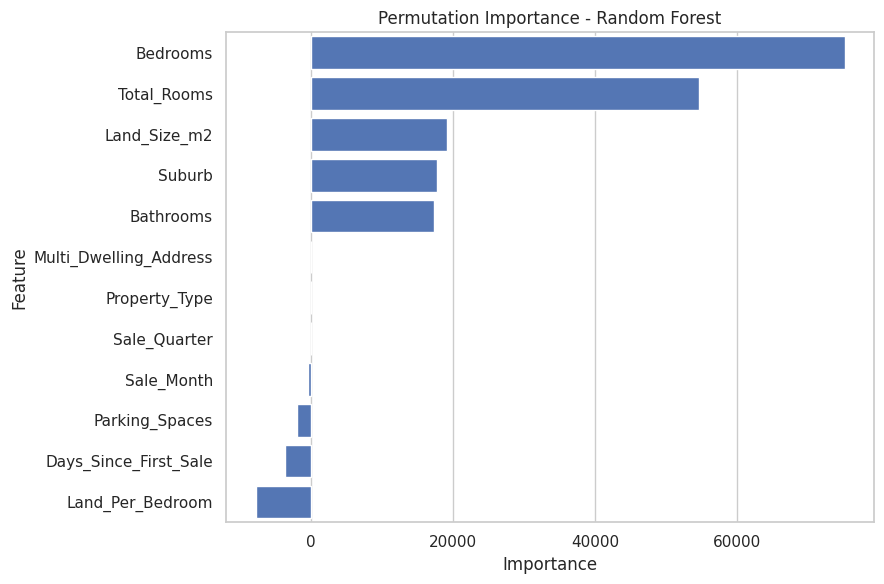

In [21]:
importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", color="#4472C4")
plt.title(f"Permutation Importance - {best_model_name}")
plt.tight_layout()
plt.savefig("06_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

In [22]:
test_predictions = best_model.predict(X_test)

failure_analysis = model_df.loc[test_idx, [
    "Property_ID", "Address", "Suburb", "Sale_Price_AUD",
    "Bedrooms", "Bathrooms", "Parking_Spaces", "Land_Size_m2",
    "Property_Type", "Listing_URL"
]].copy()

failure_analysis["Predicted_Price"] = test_predictions
failure_analysis["Absolute_Error"] = np.abs(
    failure_analysis["Sale_Price_AUD"] - failure_analysis["Predicted_Price"]
)
failure_analysis["Percentage_Error"] = (
    failure_analysis["Absolute_Error"] / failure_analysis["Sale_Price_AUD"] * 100
)

top_five_failures = failure_analysis.nlargest(5, "Absolute_Error")
display(top_five_failures.round(2))
top_five_failures.to_csv("top_five_prediction_failures.csv", index=False)

,Property_ID,Address,Suburb,Sale_Price_AUD,Bedrooms,Bathrooms,Parking_Spaces,Land_Size_m2,Property_Type,Listing_URL,Predicted_Price,Absolute_Error,Percentage_Error
77,SYD-078,"1 leitz street, Liverpool",Liverpool,3100000,24,14,6.0,1358.0,House,https://www.realestate.com.au/sold/property-ho...,1840586.38,1259413.62,40.63
99,SYD-100,"24 Rose Street, Liverpool",Liverpool,1732000,5,2,2.0,815.0,House,https://www.realestate.com.au/sold/property-ho...,1435668.21,296331.79,17.11
53,SYD-054,"5 Lachlan Place, Campbelltown",Campbelltown,990000,3,1,2.0,961.0,House,https://www.realestate.com.au/sold/property-ho...,1212545.30,222545.30,22.48
31,SYD-032,"28 Flyer Glade, Blacktown",Blacktown,870000,2,2,1.0,NaN,House,https://www.realestate.com.au/sold/property-ho...,668183.40,201816.60,23.20
104,SYD-105,"4/10 Tobruk Avenue, Liverpool",Liverpool,945000,3,2,2.0,NaN,House,https://www.realestate.com.au/sold/property-ho...,1099050.04,154050.04,16.30


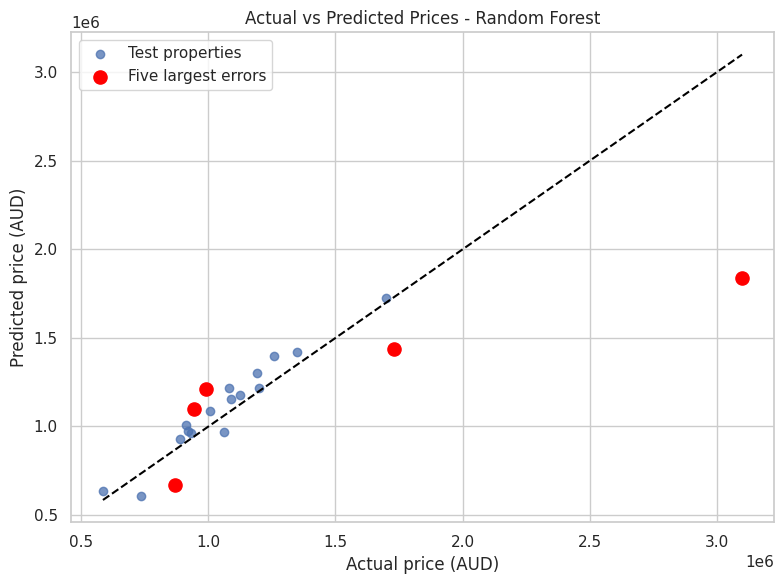

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_predictions, alpha=0.75, label="Test properties")
plt.scatter(
    top_five_failures["Sale_Price_AUD"],
    top_five_failures["Predicted_Price"],
    color="red", s=90, label="Five largest errors"
)

line_min = min(y_test.min(), test_predictions.min())
line_max = max(y_test.max(), test_predictions.max())
plt.plot([line_min, line_max], [line_min, line_max], "--", color="black")
plt.xlabel("Actual price (AUD)")
plt.ylabel("Predicted price (AUD)")
plt.title(f"Actual vs Predicted Prices - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig("07_prediction_failures.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
comparison_10 = failure_analysis.sample(
    n=min(10, len(failure_analysis)),
    random_state=RANDOM_STATE
).copy()

comparison_10["LLM_Estimate"] = np.nan
comparison_10["Human_Estimate"] = np.nan

def make_llm_prompt(row):
    return (
        f"Estimate the sale price in AUD for this Sydney property. "
        f"Suburb: {row['Suburb']}; property type: {row['Property_Type']}; "
        f"bedrooms: {row['Bedrooms']}; bathrooms: {row['Bathrooms']}; "
        f"parking spaces: {row['Parking_Spaces']}; land size: {row['Land_Size_m2']} m2. "
        f"Give one price estimate only and briefly explain it."
    )

comparison_10["LLM_Prompt"] = comparison_10.apply(make_llm_prompt, axis=1)
display(comparison_10[[
    "Property_ID", "Suburb", "Bedrooms", "Bathrooms",
    "Parking_Spaces", "Land_Size_m2", "LLM_Prompt"
]])

comparison_10.to_csv("ten_property_estimate_template.csv", index=False)
print("Use each prompt with the same LLM, then enter its estimate in the next cell.")

,Property_ID,Suburb,Bedrooms,Bathrooms,Parking_Spaces,Land_Size_m2,LLM_Prompt
30,SYD-031,Blacktown,7,4,2.0,584.0,Estimate the sale price in AUD for this Sydney...
33,SYD-034,Blacktown,5,2,1.0,550.0,Estimate the sale price in AUD for this Sydney...
4,SYD-005,Blacktown,5,3,6.0,NaN,Estimate the sale price in AUD for this Sydney...
65,SYD-066,Campbelltown,3,1,1.0,556.0,Estimate the sale price in AUD for this Sydney...
10,SYD-011,Blacktown,3,1,1.0,575.4,Estimate the sale price in AUD for this Sydney...
94,SYD-095,Liverpool,2,1,1.0,135.0,Estimate the sale price in AUD for this Sydney...
31,SYD-032,Blacktown,2,2,1.0,NaN,Estimate the sale price in AUD for this Sydney...
53,SYD-054,Campbelltown,3,1,2.0,961.0,Estimate the sale price in AUD for this Sydney...
12,SYD-013,Blacktown,3,2,4.0,651.0,Estimate the sale price in AUD for this Sydney...
80,SYD-081,Liverpool,3,1,4.0,664.0,Estimate the sale price in AUD for this Sydney...


Use each prompt with the same LLM, then enter its estimate in the next cell.


In [25]:
llm_estimates = [1400000,
                 1200000,
                 1500000,
                 950000,
                 1090000,
                 650000,
                 950000,
                 1080000,
                 1180000,
                 1220000
                 ]
human_estimates = [1200000,
                   1100000,
                   1300000,
                   900000,
                   1000000,
                   600000,
                   850000,
                   1000000,
                   1100000,
                   1200000
                   ]

if len(llm_estimates) == len(comparison_10) and len(human_estimates) == len(comparison_10):
    comparison_10["LLM_Estimate"] = llm_estimates
    comparison_10["Human_Estimate"] = human_estimates
    print("Estimates added successfully.")
else:
    print(f"Enter {len(comparison_10)} LLM estimates and {len(comparison_10)} human estimates before continuing.")

Estimates added successfully.


,Property_ID,Address,Suburb,Sale_Price_AUD,Bedrooms,Bathrooms,Parking_Spaces,Land_Size_m2,Property_Type,Listing_URL,Predicted_Price,Absolute_Error,Percentage_Error,LLM_Estimate,Human_Estimate,LLM_Prompt,ML_Absolute_Error,LLM_Absolute_Error,Human_Absolute_Error
30,SYD-031,"53 Pelleas Street, Blacktown",Blacktown,1700000,7,4,2.0,584.0,House,https://www.realestate.com.au/sold/property-ho...,1728212.05,28212.05,1.66,1400000,1200000,Estimate the sale price in AUD for this Sydney...,28212.05,300000,500000
33,SYD-034,"9 Nicholas Street, Blacktown",Blacktown,1200000,5,2,1.0,550.0,House,https://www.realestate.com.au/sold/property-ho...,1217449.77,17449.77,1.45,1200000,1100000,Estimate the sale price in AUD for this Sydney...,17449.77,0,100000
4,SYD-005,"42 Burke Street, Blacktown",Blacktown,1260000,5,3,6.0,NaN,House,https://www.realestate.com.au/sold/property-ho...,1399099.66,139099.66,11.04,1500000,1300000,Estimate the sale price in AUD for this Sydney...,139099.66,240000,40000
65,SYD-066,"3 Albury Avenue, Campbelltown",Campbelltown,920000,3,1,1.0,556.0,House,https://www.realestate.com.au/sold/property-ho...,972847.16,52847.16,5.74,950000,900000,Estimate the sale price in AUD for this Sydney...,52847.16,30000,20000
10,SYD-011,"19 Stephen Street, Blacktown",Blacktown,1062500,3,1,1.0,575.4,House,https://www.realestate.com.au/sold/property-ho...,966238.64,96261.36,9.06,1090000,1000000,Estimate the sale price in AUD for this Sydney...,96261.36,27500,62500
94,SYD-095,"11B Mclean Street, Liverpool",Liverpool,735000,2,1,1.0,135.0,House,https://www.realestate.com.au/sold/property-ho...,604739.22,130260.78,17.72,650000,600000,Estimate the sale price in AUD for this Sydney...,130260.78,85000,135000
31,SYD-032,"28 Flyer Glade, Blacktown",Blacktown,870000,2,2,1.0,NaN,House,https://www.realestate.com.au/sold/property-ho...,668183.40,201816.60,23.20,950000,850000,Estimate the sale price in AUD for this Sydney...,201816.60,80000,20000
53,SYD-054,"5 Lachlan Place, Campbelltown",Campbelltown,990000,3,1,2.0,961.0,House,https://www.realestate.com.au/sold/property-ho...,1212545.30,222545.30,22.48,1080000,1000000,Estimate the sale price in AUD for this Sydney...,222545.30,90000,10000
12,SYD-013,"36 Bedford Road, Blacktown",Blacktown,1007500,3,2,4.0,651.0,House,https://www.realestate.com.au/sold/property-ho...,1088400.32,80900.32,8.03,1180000,1100000,Estimate the sale price in AUD for this Sydney...,80900.32,172500,92500
80,SYD-081,"133 Orange Grove Road, Liverpool",Liverpool,1090000,3,1,4.0,664.0,House,https://www.realestate.com.au/sold/property-ho...,1157956.64,67956.64,6.23,1220000,1200000,Estimate the sale price in AUD for this Sydney...,67956.64,130000,110000


,Approach,MAE,RMSE
0,Machine Learning,103734.96,122839.48
1,Large Language Model,115500.00,147525.42
2,Human,109000.00,174724.78


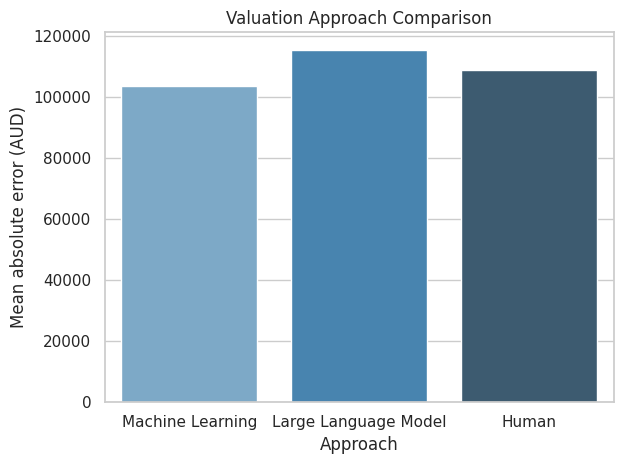

In [26]:

required = ["LLM_Estimate", "Human_Estimate"]

if comparison_10[required].notna().all().all():
    comparison_10["ML_Absolute_Error"] = abs(comparison_10["Sale_Price_AUD"] - comparison_10["Predicted_Price"])
    comparison_10["LLM_Absolute_Error"] = abs(comparison_10["Sale_Price_AUD"] - comparison_10["LLM_Estimate"])
    comparison_10["Human_Absolute_Error"] = abs(comparison_10["Sale_Price_AUD"] - comparison_10["Human_Estimate"])

    approach_results = pd.DataFrame({
        "Approach": ["Machine Learning", "Large Language Model", "Human"],
        "MAE": [
            comparison_10["ML_Absolute_Error"].mean(),
            comparison_10["LLM_Absolute_Error"].mean(),
            comparison_10["Human_Absolute_Error"].mean()
        ],
        "RMSE": [
            np.sqrt(np.mean((comparison_10["Sale_Price_AUD"] - comparison_10["Predicted_Price"]) ** 2)),
            np.sqrt(np.mean((comparison_10["Sale_Price_AUD"] - comparison_10["LLM_Estimate"]) ** 2)),
            np.sqrt(np.mean((comparison_10["Sale_Price_AUD"] - comparison_10["Human_Estimate"]) ** 2))
        ]
    })

    display(comparison_10.round(2))
    display(approach_results.round(2))

    sns.barplot(data=approach_results, x="Approach", y="MAE", palette="Blues_d")
    plt.title("Valuation Approach Comparison")
    plt.ylabel("Mean absolute error (AUD)")
    plt.tight_layout()
    plt.savefig("08_human_llm_ml_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

    comparison_10.to_csv("completed_ten_property_comparison.csv", index=False)
else:
    print("Complete Cell 23 with genuine estimates before running this comparison.")

In [27]:

final_model = pipelines[best_model_name]
final_model.fit(X, y)

model_bundle = {
    "model": final_model,
    "feature_columns": feature_columns,
    "first_sale_date": model_df["Sale_Date"].min(),
    "model_name": best_model_name
}

joblib.dump(model_bundle, "best_house_price_model.joblib")
print("Saved model:", best_model_name)

Saved model: Random Forest


In [28]:
!pip -q install gradio

print("Gradio installed successfully.")

Gradio installed successfully.


In [29]:

app_source = r'''import joblib
import numpy as np
import pandas as pd
import gradio as gr

bundle = joblib.load("best_house_price_model.joblib")
model = bundle["model"]
feature_columns = bundle["feature_columns"]
first_sale_date = pd.Timestamp(bundle["first_sale_date"])

def predict_price(suburb, property_type, sale_date, bedrooms, bathrooms,
                  parking_spaces, land_size, multi_dwelling):
    sale_date = pd.to_datetime(sale_date)
    bedrooms = float(bedrooms)
    bathrooms = float(bathrooms)
    land_value = np.nan if land_size is None else float(land_size)

    row = pd.DataFrame([{
        "Bedrooms": bedrooms,
        "Bathrooms": bathrooms,
        "Parking_Spaces": parking_spaces,
        "Land_Size_m2": land_value,
        "Total_Rooms": bedrooms + bathrooms,
        "Land_Per_Bedroom": land_value / bedrooms if bedrooms > 0 else np.nan,
        "Sale_Month": sale_date.month,
        "Sale_Quarter": sale_date.quarter,
        "Days_Since_First_Sale": (sale_date - first_sale_date).days,
        "Multi_Dwelling_Address": int(multi_dwelling),
        "Suburb": suburb,
        "Property_Type": property_type
    }])[feature_columns]

    prediction = model.predict(row)[0]
    return f"Estimated sale price: ${prediction:,.0f} AUD"

demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Dropdown(["Blacktown", "Campbelltown", "Liverpool"], label="Suburb"),
        gr.Dropdown(["House", "Apartment", "Townhouse", "Duplex", "Other"], value="House", label="Property type"),
        gr.Textbox(value="2026-09-17", label="Expected sale date (YYYY-MM-DD)"),
        gr.Number(value=3, label="Bedrooms"),
        gr.Number(value=2, label="Bathrooms"),
        gr.Number(value=1, label="Parking spaces"),
        gr.Number(value=500, label="Land size (m²)"),
        gr.Checkbox(label="Multiple dwellings shown in address")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Sydney Housing Price Predictor",
    description="Educational estimate based on 105 recent sold properties. Do not use as a professional valuation."
)

if __name__ == "__main__":
    demo.launch(share=True)
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_source)

print("app.py created successfully.")

app.py created successfully.


In [ ]:
!python app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://358834893346397c0b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
